# PAKE YANG INI YA!

## Tahap Awal (Import dan labeling)

In [1]:
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# ==========================================
# 2. FUNGSI PEMBACA GROUND TRUTH
# ==========================================
import os

def tentukan_label_dari_yolo(txt_path):
    if not os.path.exists(txt_path):
        return "Bebas Jerawat", 0, 0.0, 0.0

    jumlah_jerawat_asli = 0
    luas_total_asli = 0.0
    luas_terbesar = 0.0

    with open(txt_path, 'r') as file:
        baris = file.readlines()
        jumlah_jerawat_asli = len(baris)
        for b in baris:
            data = b.strip().split()
            if len(data) == 5:
                lebar, tinggi = float(data[3]), float(data[4])
                luas_kotak = lebar * tinggi
                luas_total_asli += luas_kotak
                if luas_kotak > luas_terbesar: luas_terbesar = luas_kotak

    # SOP Klasifikasi 4 Kelas yang Logis
    if jumlah_jerawat_asli == 0:
        kategori = "Bebas Jerawat"
    elif jumlah_jerawat_asli < 15 and luas_total_asli < 0.03 and luas_terbesar < 0.01:
        kategori = "Ringan"
    elif jumlah_jerawat_asli > 35 or luas_total_asli > 0.10 or luas_terbesar > 0.03:
        kategori = "Parah"
    else:
        kategori = "Sedang"

    return kategori, jumlah_jerawat_asli, luas_terbesar, luas_total_asli

## CLAHE (SKIN MASKING) + TRAINING YOLOV8N

In [ ]:
import os
import cv2
import numpy as np
import shutil

# ==========================================
# SCRIPT PENCUCIAN DATASET (TRAIN & VAL)
# ==========================================

# Kita daftar folder apa saja yang mau dicuci
# Sesuaikan 'valid' jika nama foldermu di PC adalah 'val'
kategori_dataset = ['train', 'valid']

# Siapkan alat CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

for kategori in kategori_dataset:
    folder_img_asal = f'data/{kategori}/images'
    folder_lbl_asal = f'data/{kategori}/labels'

    folder_img_baru = f'data/{kategori}_prep/images'
    folder_lbl_baru = f'data/{kategori}_prep/labels'

    os.makedirs(folder_img_baru, exist_ok=True)
    os.makedirs(folder_lbl_baru, exist_ok=True)

    foto_kategori = [f for f in os.listdir(folder_img_asal) if f.endswith(('.jpg', '.png'))]
    print(f"Memulai pencucian {len(foto_kategori)} gambar dari folder '{kategori}'...")

    for nama_foto in foto_kategori:
        path_img = os.path.join(folder_img_asal, nama_foto)
        img = cv2.imread(path_img)
        if img is None: continue

        # --- TAHAP A: MASKING KULIT ---
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        img_YCrCb = cv2.cvtColor(img_blur, cv2.COLOR_BGR2YCrCb)
        lower_skin = np.array([0, 133, 77], dtype=np.uint8)
        upper_skin = np.array([255, 173, 127], dtype=np.uint8)
        mask = cv2.inRange(img_YCrCb, lower_skin, upper_skin)

        # --- TAHAP B: CLAHE (Pemerataan Kontras) ---
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe, a, b))
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

        # --- TAHAP C: GABUNGKAN ---
        img_final = cv2.bitwise_and(img_clahe, img_clahe, mask=mask)

        # 2. Simpan gambar hasil cucian
        path_simpan_img = os.path.join(folder_img_baru, nama_foto)
        cv2.imwrite(path_simpan_img, img_final)

        # 3. Copy file TXT (kunci jawaban)
        nama_txt = os.path.splitext(nama_foto)[0] + '.txt'
        path_txt_asal = os.path.join(folder_lbl_asal, nama_txt)
        if os.path.exists(path_txt_asal):
            shutil.copy(path_txt_asal, os.path.join(folder_lbl_baru, nama_txt))

print("\nPencucian massal SELESAI!")
print("Sekarang di file 'dataset_jerawat.yaml', ubah path-nya jadi:")
print("train: train_prep/images")
print("val: valid_prep/images")

Memulai pencucian 823 gambar dari folder 'train'...
Memulai pencucian 56 gambar dari folder 'valid'...

Pencucian massal SELESAI!
Sekarang di file 'dataset_jerawat.yaml', ubah path-nya jadi:
train: train_prep/images
val: valid_prep/images


In [ ]:
import yaml
import os

# 1. Mendefinisikan rute folder dan nama kelas
# Karena YOLO cuma cari jerawat, jumlah kelasnya (nc) cukup 1
yaml_data = {
    'path': os.path.abspath('data'), # Mencari path absolut folder data-mu
    'train': 'train_prep/images',         # Jalur ke gambar latihan
    'val': 'valid_prep/images',             # Jalur ke gambar validasi
    'nc': 1,                         # Jumlah kelas (Number of Classes)
    'names': ['jerawat']             # Nama kelasnya
}

# 2. Menciptakan file dataset_jerawat.yaml
with open('dataset_jerawat_yolov8n_skin_mask.yaml', 'w') as file:
    yaml.dump(yaml_data, file, default_flow_style=False)

print("data yaml berhasil dibuat! YOLO siap dilatih.")

data yaml berhasil dibuat! YOLO siap dilatih.


In [ ]:
from ultralytics import YOLO

# Muat model nano
model = YOLO('yolov8n.pt')

# Latih dengan kesabaran 20 epoch
results = model.train(
    data='dataset_jerawat_yolov8n_skin_mask.yaml',
    epochs=100,
    patience=20, # Sangat aman dan ideal
    imgsz=640
)
# Begitu selesai, LANGSUNG gunakan file 'runs/detect/train/weights/best.pt'

New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.14.4 torch-2.11.0+cpu CPU (AMD Ryzen 5 6600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_jerawat_yolov8n_skin_mask.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, mu

In [ ]:
from ultralytics import YOLO
import os
import cv2
import pandas as pd
import numpy as np

# ==========================================
# 3. PROSES EKSTRAKSI FITUR (YOLOv8 + ML PIPELINE)
# ==========================================

# 1. Panggil "Mata" YOLO yang sudah kamu latih
path_model_yolo = 'runs/detect/train/weights/best.pt'
model_yolo = YOLO(path_model_yolo)

# --- PERBAIKAN DI SINI ---
# Definisikan dengan jelas variabel foldernya ke lokasi data yang sudah di-masking
folder_images = 'data/train_prep/images'
folder_labels = 'data/train_prep/labels'
# -------------------------

data_tabular = []
ekstensi_valid = ('.jpg', '.jpeg', '.png')

# Sekarang listdir memanggil nama variabelnya secara konsisten
semua_foto = [f for f in os.listdir(folder_images) if f.lower().endswith(ekstensi_valid)]

print(f"Total gambar ditemukan: {len(semua_foto)}")
print("Memulai pemindaian jerawat menggunakan radar YOLOv8...\n")

for nama_foto in semua_foto:
    # Karena folder_images dan folder_labels sudah didefinisikan, baris ini jadi aman
    path_foto = os.path.join(folder_images, nama_foto)
    nama_txt = os.path.splitext(nama_foto)[0] + '.txt'
    path_txt = os.path.join(folder_labels, nama_txt)

    # 1. AMBIL KUNCI JAWABAN ASLI FULL (Label + Angka Statistik)
    kategori_label = "Bebas Jerawat"
    jml_asli = 0
    luas_max_asli = 0.0
    luas_tot_asli = 0.0

    if os.path.exists(path_txt) or (os.path.exists(path_txt) and os.path.getsize(path_txt) == 0):
        # Ambil semua 4 nilai yang di-return oleh fungsi pembaca txt
        kategori_label, jml_asli, luas_max_asli, luas_tot_asli = tentukan_label_dari_yolo(path_txt)

    img = cv2.imread(path_foto)
    if img is None: continue

    h_img, w_img, _ = img.shape
    luas_kanvas = h_img * w_img

    # 2. YOLO MENDETEKSI GAMBAR
    hasil_prediksi = model_yolo.predict(source=img, conf=0.25, verbose=False)

    # Ambil data kotak (Bounding Boxes) hasil tebakan YOLO
    kotak_yolo = hasil_prediksi[0].boxes.xywh.cpu().numpy()
    skor_yolo = hasil_prediksi[0].boxes.conf.cpu().numpy()

    jml_jerawat_sistem = len(kotak_yolo)
    luas_total_sys_px = 0.0
    luas_terbesar_sys_px = 0.0

    # 3. HITUNG STATISTIK KOTAK (Untuk dikirim ke algoritma Klasifikasi)
    for kotak in kotak_yolo:
        w, h = kotak[2], kotak[3]
        area_px = w * h

        luas_total_sys_px += area_px
        if area_px > luas_terbesar_sys_px:
            luas_terbesar_sys_px = area_px

    # Normalisasi rasio area
    luas_terbesar_norm = luas_terbesar_sys_px / luas_kanvas if luas_kanvas > 0 else 0
    luas_total_norm = luas_total_sys_px / luas_kanvas if luas_kanvas > 0 else 0

    # Kalau tidak ada jerawat (array kosong), keyakinannya 0.
    rata_conf = float(np.mean(skor_yolo)) if jml_jerawat_sistem > 0 else 0.0

    # 4. SIMPAN KE TABEL
    data_tabular.append({
        'nama_file': nama_foto,
        'jml_jerawat_yolo': jml_jerawat_sistem,
        'luas_terbesar_yolo': luas_terbesar_norm,
        'luas_area_yolo': luas_total_norm,
        'rata_conf_yolo': rata_conf,

        # --- KENYATAAN ASLI (GROUND TRUTH) ---
        'jml_jerawat_asli': jml_asli,
        'luas_terbesar_asli': luas_max_asli,
        'luas_area_asli': luas_tot_asli,

        'label_keparahan': kategori_label
    })

# Buat CSV baru khusus data YOLO (kamu pakai model small di sini, namanya sudah pas)
df = pd.DataFrame(data_tabular)
df.to_csv('dataset_jerawat_yolov8s_ml.csv', index=False)

print("="*45)
print("EKSTRAKSI YOLO SELESAI!")
print(f"Total Baris Data : {len(df)}")
print("="*45)

Total gambar ditemukan: 823
Memulai pemindaian jerawat menggunakan radar YOLOv8...

EKSTRAKSI YOLO SELESAI!
Total Baris Data : 823


In [ ]:
df_parah = df[df['label_keparahan']=='Bebas Jerawat']
df_parah

,nama_file,jml_jerawat_yolo,luas_terbesar_yolo,luas_area_yolo,rata_conf_yolo,jml_jerawat_asli,luas_terbesar_asli,luas_area_asli,label_keparahan
120,acne-182_jpg.rf.003ad78b62a47fe0c61d19fd1df199...,1,0.002612,0.002612,0.398065,0,0.0,0.0,Bebas Jerawat
121,acne-182_jpg.rf.7c2e3699a804e6c8aa7910f55b5ca1...,2,0.002993,0.004657,0.290303,0,0.0,0.0,Bebas Jerawat
122,acne-182_jpg.rf.a5a32d648c2879bb9c344f40f540aa...,0,0.000000,0.000000,0.000000,0,0.0,0.0,Bebas Jerawat
348,acne-287_jpeg.rf.0e3351b30d0ffeee1c87427015114...,3,0.011582,0.018363,0.399851,0,0.0,0.0,Bebas Jerawat
349,acne-287_jpeg.rf.26a033f8acf312e5ae68de86a886b...,3,0.005760,0.012401,0.294229,0,0.0,0.0,Bebas Jerawat
350,acne-287_jpeg.rf.2f8ab412b79cdc05c82405422d9da...,4,0.011702,0.028194,0.360980,0,0.0,0.0,Bebas Jerawat
432,acne-317_jpeg.rf.46ed7951f87afb2e53a0f78fa5f78...,3,0.015182,0.021263,0.395912,0,0.0,0.0,Bebas Jerawat
433,acne-317_jpeg.rf.67150dd365e3698fce482a944e674...,4,0.017090,0.030440,0.422109,0,0.0,0.0,Bebas Jerawat
434,acne-317_jpeg.rf.7b7d3ede64a00397babad2c3fa9f8...,3,0.015394,0.021814,0.388685,0,0.0,0.0,Bebas Jerawat
532,acne-371_jpeg.rf.363bbc85d736aae294e6a79d7cd55...,4,0.007588,0.020697,0.353690,0,0.0,0.0,Bebas Jerawat


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 6. PERSIAPAN DATA (MURNI TANPA OVERSAMPLING)
# ==========================================
df_ml = pd.read_csv('dataset_jerawat_yolov8s_ml.csv')

# X (Fitur Input): Pastikan ada 4 kolom, termasuk senjata baru kita!
X = df_ml[['jml_jerawat_yolo', 'luas_terbesar_yolo', 'luas_area_yolo', 'rata_conf_yolo']]
y = df_ml['label_keparahan']

# Pisahkan 80% Latih, 20% Ujian dengan STRATIFY agar kelas langka tidak punah di satu sisi!
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Normalisasi agar setara
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data latih siap: {len(X_train_scaled)} baris)")

Data latih siap: 658 baris)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# ==========================================
# 7. PELATIHAN MODEL (BENCHMARK 5 ALGORITMA)
# ==========================================

# --- PERSIAPAN KHUSUS XGBOOST ---
# 1. Ubah label teks ("Ringan", "Parah") jadi angka (0, 1, 2, 3)
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)

# 2. Hitung bobot pinalti agar kelas yang datanya sedikit tetap diperhatikan
bobot_seimbang_xgb = compute_sample_weight(class_weight='balanced', y=y_train)

# 1. Inisialisasi model (SVM pakai balanced, KNN pakai distance)
model_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
model_knn = KNeighborsClassifier(n_neighbors=5, weights='distance') # <--- Tidak ada class_weight
model_xgboost = XGBClassifier(objective='multi:softmax', num_class=4, random_state=42)

# 2. Ajari semua model pakai data murni (X_train_scaled)
print("Sedang melatih model Decision Tree...")
model_dt.fit(X_train_scaled, y_train)

print("Sedang melatih model Random Forest...")
model_rf.fit(X_train_scaled, y_train)

print("Sedang melatih model Logistic Regression...")
model_lr.fit(X_train_scaled, y_train)

print("Sedang melatih model SVM...")
model_svm.fit(X_train_scaled, y_train)

print("Sedang melatih model KNN...")
model_knn.fit(X_train_scaled, y_train)

print("Sedang melatih model XGBoost...")
model_xgboost.fit(X_train_scaled, y_train_xgb, sample_weight=bobot_seimbang_xgb)

print("\nPelatihan 6 Algoritma selesai! Mesin siap diuji.")

Sedang melatih model Decision Tree...
Sedang melatih model Random Forest...
Sedang melatih model Logistic Regression...
Sedang melatih model SVM...
Sedang melatih model KNN...
Sedang melatih model XGBoost...

Pelatihan 6 Algoritma selesai! Mesin siap diuji.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 8. EVALUASI MODEL (CETAK RAPOR 6 ALGORITMA)
# ==========================================

# 1. Bungkus kelima model yang sudah pintar ke dalam satu "Daftar Absen"
daftar_model = {
    "DECISION TREE": model_dt,
    "RANDOM FOREST": model_rf,
    "LOGISTIC REGRESSION": model_lr,
    "SUPPORT VECTOR MACHINE (SVM)": model_svm,
    "K-NEAREST NEIGHBORS (KNN)": model_knn,
    "XGBOOST (XGB)" : model_xgboost
}

print("="*55)
print("MEMULAI UJIAN NASIONAL MACHINE LEARNING...")
print("="*55)

# 2. Panggil mereka satu per satu untuk mengerjakan soal ujian (X_test_scaled)
for nama_model, mesin in daftar_model.items():
    # Mesin disuruh menebak jawaban dari soal ujian
    tebakan_mesin = mesin.predict(X_test_scaled)

    # --- PENYESUAIAN KHUSUS XGBOOST ---
    # Jika yang sedang ujian adalah XGBoost, terjemahkan dulu angka ke teks
    if nama_model == "XGBOOST (XGB)":
        tebakan_mesin = le.inverse_transform(tebakan_mesin)

    # Kita cocokkan tebakan mesin dengan Kunci Jawaban Asli (y_test)
    akurasi = accuracy_score(y_test, tebakan_mesin)
    rapor_detail = classification_report(y_test, tebakan_mesin, zero_division=0)

    # 3. Cetak rapornya ke layar
    print(f"\nHASIL UJIAN MODEL: {nama_model}")
    print(f"Akurasi Keseluruhan : {akurasi * 100:.2f}%")
    print("Detail Rapor (Precision, Recall, F1-Score):")
    print(rapor_detail)
    print("-" * 55)

print("\nSemua model telah selesai diuji! Silakan bandingkan hasilnya.")

MEMULAI UJIAN NASIONAL MACHINE LEARNING...

HASIL UJIAN MODEL: DECISION TREE
Akurasi Keseluruhan : 69.70%
Detail Rapor (Precision, Recall, F1-Score):
               precision    recall  f1-score   support

Bebas Jerawat       0.14      0.50      0.22         2
        Parah       0.75      0.73      0.74        33
       Ringan       0.69      0.57      0.62        44
       Sedang       0.72      0.76      0.74        86

     accuracy                           0.70       165
    macro avg       0.58      0.64      0.58       165
 weighted avg       0.71      0.70      0.70       165

-------------------------------------------------------

HASIL UJIAN MODEL: RANDOM FOREST
Akurasi Keseluruhan : 71.52%
Detail Rapor (Precision, Recall, F1-Score):
               precision    recall  f1-score   support

Bebas Jerawat       0.00      0.00      0.00         2
        Parah       0.85      0.67      0.75        33
       Ringan       0.70      0.59      0.64        44
       Sedang       0.7

MENCETAK HEATMAP CONFUSION MATRIX UNTUK 6 ALGORITMA


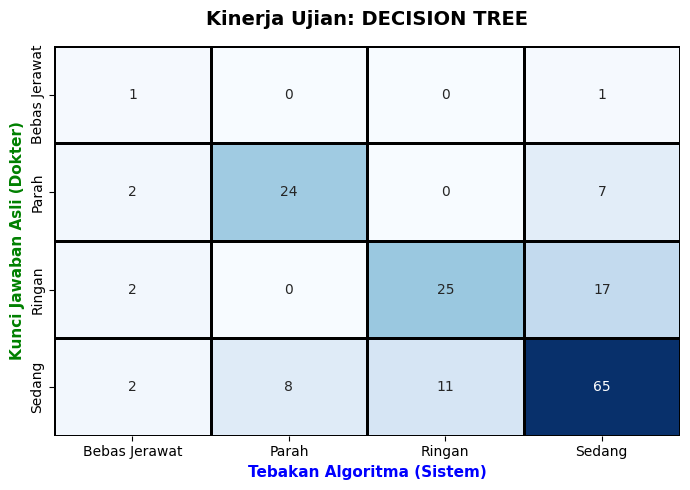

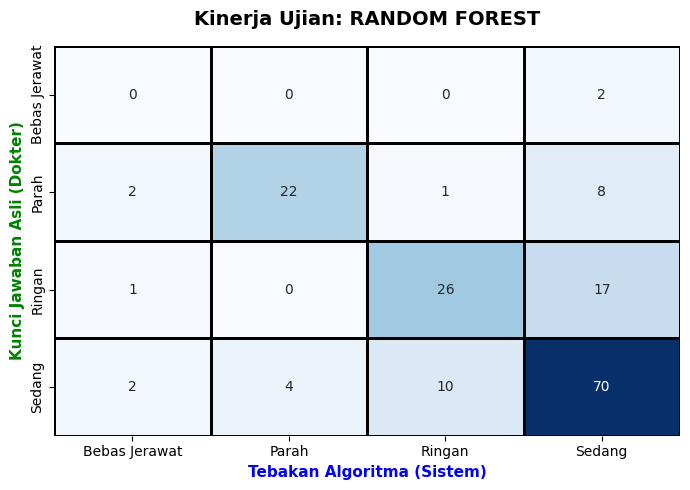

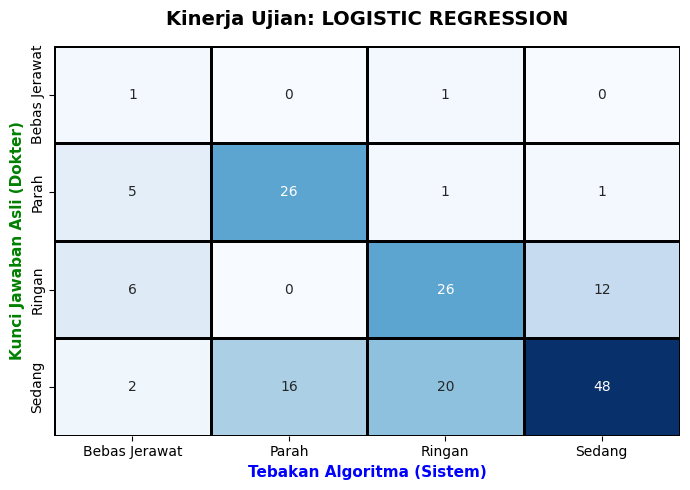

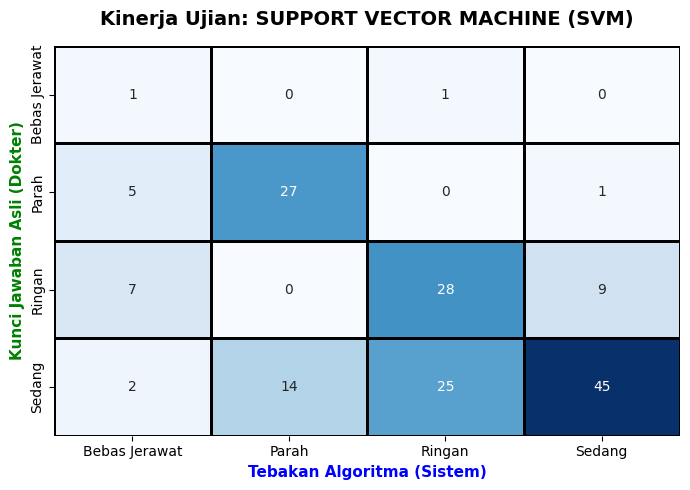

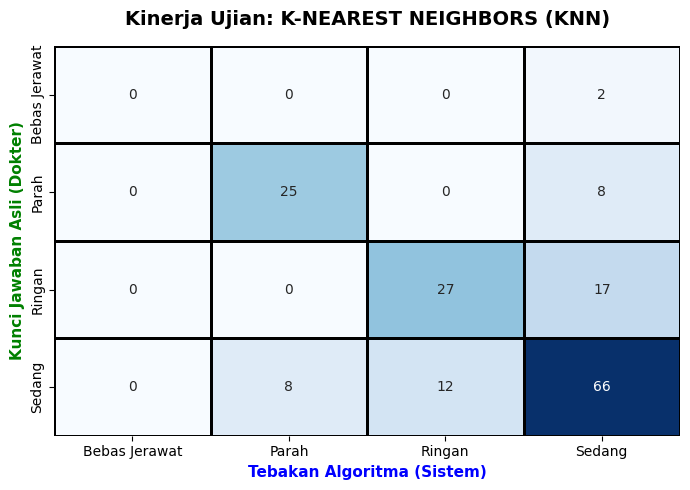

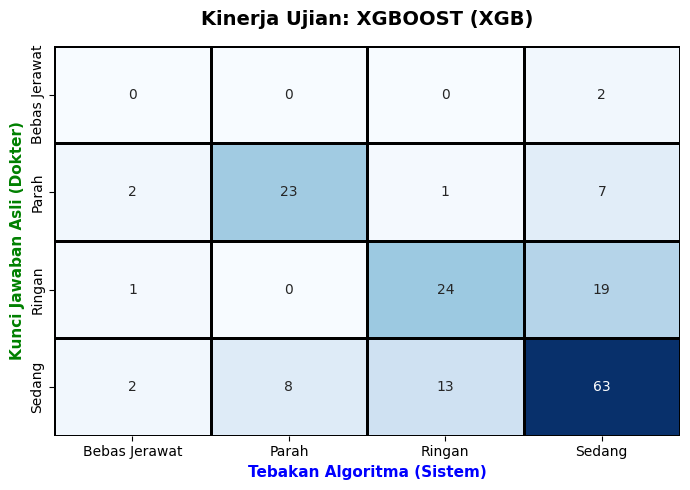

In [ ]:
from sklearn.metrics import confusion_matrix

# ==========================================
# 9. VISUALISASI RAPOR (CONFUSION MATRIX HEATMAP)
# ==========================================

# Ambil urutan kategori yang benar dari data ujian agar urutannya rapi
label_kelas = np.unique(y_test)

print("="*55)
print("MENCETAK HEATMAP CONFUSION MATRIX UNTUK 6 ALGORITMA")
print("="*55)

# Loop untuk menggambar heatmap setiap mesin yang sudah ujian
for nama_model, mesin in daftar_model.items():
    # Suruh mesin menebak ulang dari soal ujian
    tebakan_mesin = mesin.predict(X_test_scaled)

    # --- PENYELAMAT KHUSUS XGBOOST ---
    # Terjemahkan dulu angka sandi XGBoost jadi teks biasa
    if nama_model == "XGBOOST (XGB)":
        tebakan_mesin = le.inverse_transform(tebakan_mesin)

    # Hitung matriks kebingungannya (Confusion Matrix)
    cm = confusion_matrix(y_test, tebakan_mesin, labels=label_kelas)

    # Atur ukuran kanvas gambar biar pas, tidak terlalu besar/kecil
    plt.figure(figsize=(7, 5))

    # Gambar heatmap pakai Seaborn
    # fmt='d' artinya tampilkan angka utuh (bukan desimal/eksponensial)
    # cmap='Blues' untuk gradasi warna biru (makin gelap makin banyak angkanya)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=label_kelas, yticklabels=label_kelas,
                linewidths=1, linecolor='black')

    # Kasih judul dan label yang jelas
    plt.title(f'Kinerja Ujian: {nama_model}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Tebakan Algoritma (Sistem)', fontsize=11, fontweight='bold', color='blue')
    plt.ylabel('Kunci Jawaban Asli (Dokter)', fontsize=11, fontweight='bold', color='green')

    # Tampilkan gambarnya!
    plt.tight_layout()
    plt.show()

In [ ]:
import os
import cv2
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# UJIAN FINAL: MENGADU TEBAKAN VS KUNCI JAWABAN
# ==========================================

folder_test_images = 'data/test/images'
folder_test_labels = 'data/test/labels'

y_kunci_jawaban = []
y_tebakan_mesin = []

ekstensi_valid = ('.jpg', '.jpeg', '.png')
foto_test = [f for f in os.listdir(folder_test_images) if f.lower().endswith(ekstensi_valid)]

print(f"Memulai Ujian Final untuk {len(foto_test)} pasien dari desa seberang...\n")

# Siapkan alat cuci (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

for nama_foto in foto_test:
    path_foto = os.path.join(folder_test_images, nama_foto)
    nama_txt = os.path.splitext(nama_foto)[0] + '.txt'
    path_txt = os.path.join(folder_test_labels, nama_txt)

    # 1. AMBIL KUNCI JAWABAN DARI DOKTER ASLI
    kategori_asli, _, _, _ = tentukan_label_dari_yolo(path_txt)

    # 2. BACA GAMBAR SOAL UJIAN MENTAH
    img = cv2.imread(path_foto)
    if img is None: continue

    # --- PROSES PENCUCIAN VIRTUAL (MASKING + CLAHE) ---
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    img_YCrCb = cv2.cvtColor(img_blur, cv2.COLOR_BGR2YCrCb)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    mask = cv2.inRange(img_YCrCb, lower_skin, upper_skin)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    # img_final inilah yang bersih dan siap dimakan YOLO
    img_final = cv2.bitwise_and(img_clahe, img_clahe, mask=mask)
    # --------------------------------------------------

    h_img, w_img, _ = img_final.shape
    luas_kanvas = h_img * w_img

    # 3. MATA (YOLO) MENCARI JERAWAT DI GAMBAR YANG SUDAH DICUCI
    hasil_yolo = model_yolo.predict(source=img_final, conf=0.25, verbose=False)

    kotak_yolo = hasil_yolo[0].boxes.xywh.cpu().numpy()
    skor_yolo = hasil_yolo[0].boxes.conf.cpu().numpy() # Ambil skor keyakinan

    jml_jerawat = len(kotak_yolo)
    luas_total = 0.0
    luas_terbesar = 0.0

    for kotak in kotak_yolo:
        area_px = kotak[2] * kotak[3]
        luas_total += area_px
        if area_px > luas_terbesar:
            luas_terbesar = area_px

    luas_terbesar_norm = luas_terbesar / luas_kanvas if luas_kanvas > 0 else 0
    luas_total_norm = luas_total / luas_kanvas if luas_kanvas > 0 else 0
    rata_conf = float(np.mean(skor_yolo)) if jml_jerawat > 0 else 0.0

    # 4. OTAK (MACHINE LEARNING) MEMBERIKAN TEBAKAN
    # HATI-HATI: Pastikan fiturnya ada 4 sesuai yang kita latih tadi!
    fitur_mentah = np.array([[jml_jerawat, luas_terbesar_norm, luas_total_norm, rata_conf]])
    fitur_scaled = scaler.transform(fitur_mentah)

    # Di sini kamu bisa ganti model_rf dengan model_xgboost kalau XGBoost yang menang
    vonis_keparahan = model_rf.predict(fitur_scaled)[0]

    # 5. KUMPULKAN KERTAS UJIAN
    y_kunci_jawaban.append(kategori_asli)
    y_tebakan_mesin.append(vonis_keparahan)

# ==========================================
# PEMBAGIAN RAPOR AKHIR
# ==========================================
print("\n" + "="*55)
print("HASIL UJIAN FINAL (DATA TEST UNSEEN)")
print("="*55)
akurasi_final = accuracy_score(y_kunci_jawaban, y_tebakan_mesin)
print(f"Akurasi Keseluruhan : {akurasi_final * 100:.2f}%\n")
print("Detail Rapor (Precision, Recall, F1-Score):")
print(classification_report(y_kunci_jawaban, y_tebakan_mesin, zero_division=0))
print("="*55)

Memulai Ujian Final untuk 48 pasien dari desa seberang...



c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: U


HASIL UJIAN FINAL (DATA TEST UNSEEN)
Akurasi Keseluruhan : 68.75%

Detail Rapor (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       Parah       0.33      0.50      0.40         2
      Ringan       0.75      0.50      0.60        18
      Sedang       0.70      0.82      0.75        28

    accuracy                           0.69        48
   macro avg       0.59      0.61      0.58        48
weighted avg       0.70      0.69      0.68        48



c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## YOLOV8N SKIN MASK

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 6. PERSIAPAN DATA (MURNI TANPA OVERSAMPLING)
# ==========================================
df_ml = pd.read_csv('dataset_jerawat_yolov8n_ml.csv')

# X (Fitur Input): Pastikan ada 4 kolom, termasuk senjata baru kita!
X = df_ml[['jml_jerawat_yolo', 'luas_terbesar_yolo', 'luas_area_yolo', 'rata_conf_yolo']]
y = df_ml['label_keparahan']

# Pisahkan 80% Latih, 20% Ujian dengan STRATIFY agar kelas langka tidak punah di satu sisi!
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Normalisasi agar setara
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data latih siap: {len(X_train_scaled)} baris)")

Data latih siap: 658 baris)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# ==========================================
# 7. PELATIHAN MODEL (BENCHMARK 5 ALGORITMA)
# ==========================================

# --- PERSIAPAN KHUSUS XGBOOST ---
# 1. Ubah label teks ("Ringan", "Parah") jadi angka (0, 1, 2, 3)
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)

# 2. Hitung bobot pinalti agar kelas yang datanya sedikit tetap diperhatikan
bobot_seimbang_xgb = compute_sample_weight(class_weight='balanced', y=y_train)

# 1. Inisialisasi model (SVM pakai balanced, KNN pakai distance)
model_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
model_knn = KNeighborsClassifier(n_neighbors=5, weights='distance') # <--- Tidak ada class_weight
model_xgboost = XGBClassifier(objective='multi:softmax', num_class=4, random_state=42)

# 2. Ajari semua model pakai data murni (X_train_scaled)
print("Sedang melatih model Decision Tree...")
model_dt.fit(X_train_scaled, y_train)

print("Sedang melatih model Random Forest...")
model_rf.fit(X_train_scaled, y_train)

print("Sedang melatih model Logistic Regression...")
model_lr.fit(X_train_scaled, y_train)

print("Sedang melatih model SVM...")
model_svm.fit(X_train_scaled, y_train)

print("Sedang melatih model KNN...")
model_knn.fit(X_train_scaled, y_train)

print("Sedang melatih model XGBoost...")
model_xgboost.fit(X_train_scaled, y_train_xgb, sample_weight=bobot_seimbang_xgb)

print("\nPelatihan 6 Algoritma selesai! Mesin siap diuji.")

Sedang melatih model Decision Tree...
Sedang melatih model Random Forest...
Sedang melatih model Logistic Regression...
Sedang melatih model SVM...
Sedang melatih model KNN...
Sedang melatih model XGBoost...

Pelatihan 6 Algoritma selesai! Mesin siap diuji.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 8. EVALUASI MODEL (CETAK RAPOR 6 ALGORITMA)
# ==========================================

# 1. Bungkus kelima model yang sudah pintar ke dalam satu "Daftar Absen"
daftar_model = {
    "DECISION TREE": model_dt,
    "RANDOM FOREST": model_rf,
    "LOGISTIC REGRESSION": model_lr,
    "SUPPORT VECTOR MACHINE (SVM)": model_svm,
    "K-NEAREST NEIGHBORS (KNN)": model_knn,
    "XGBOOST (XGB)" : model_xgboost
}

print("="*55)
print("MEMULAI UJIAN NASIONAL MACHINE LEARNING...")
print("="*55)

# 2. Panggil mereka satu per satu untuk mengerjakan soal ujian (X_test_scaled)
for nama_model, mesin in daftar_model.items():
    # Mesin disuruh menebak jawaban dari soal ujian
    tebakan_mesin = mesin.predict(X_test_scaled)

    # --- PENYESUAIAN KHUSUS XGBOOST ---
    # Jika yang sedang ujian adalah XGBoost, terjemahkan dulu angka ke teks
    if nama_model == "XGBOOST (XGB)":
        tebakan_mesin = le.inverse_transform(tebakan_mesin)

    # Kita cocokkan tebakan mesin dengan Kunci Jawaban Asli (y_test)
    akurasi = accuracy_score(y_test, tebakan_mesin)
    rapor_detail = classification_report(y_test, tebakan_mesin, zero_division=0)

    # 3. Cetak rapornya ke layar
    print(f"\nHASIL UJIAN MODEL: {nama_model}")
    print(f"Akurasi Keseluruhan : {akurasi * 100:.2f}%")
    print("Detail Rapor (Precision, Recall, F1-Score):")
    print(rapor_detail)
    print("-" * 55)

print("\nSemua model telah selesai diuji! Silakan bandingkan hasilnya.")

MEMULAI UJIAN NASIONAL MACHINE LEARNING...

HASIL UJIAN MODEL: DECISION TREE
Akurasi Keseluruhan : 67.27%
Detail Rapor (Precision, Recall, F1-Score):
               precision    recall  f1-score   support

Bebas Jerawat       0.25      0.50      0.33         2
        Parah       0.74      0.76      0.75        33
       Ringan       0.59      0.61      0.60        44
       Sedang       0.72      0.67      0.69        86

     accuracy                           0.67       165
    macro avg       0.57      0.64      0.59       165
 weighted avg       0.68      0.67      0.68       165

-------------------------------------------------------

HASIL UJIAN MODEL: RANDOM FOREST
Akurasi Keseluruhan : 73.33%
Detail Rapor (Precision, Recall, F1-Score):
               precision    recall  f1-score   support

Bebas Jerawat       0.25      0.50      0.33         2
        Parah       0.77      0.73      0.75        33
       Ringan       0.70      0.68      0.69        44
       Sedang       0.7

MENCETAK HEATMAP CONFUSION MATRIX UNTUK 6 ALGORITMA


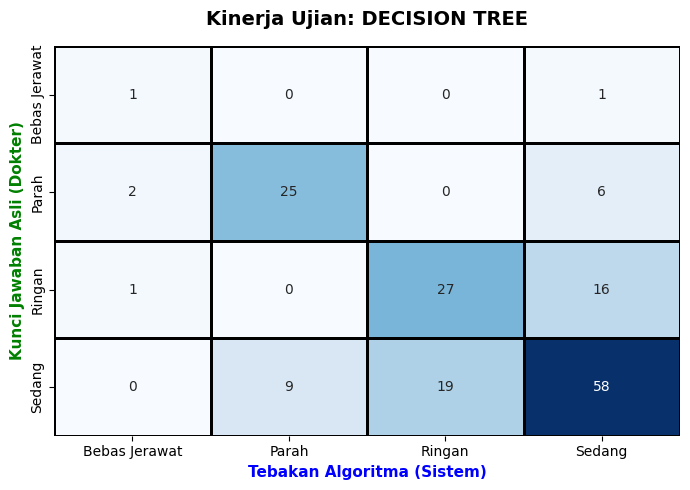

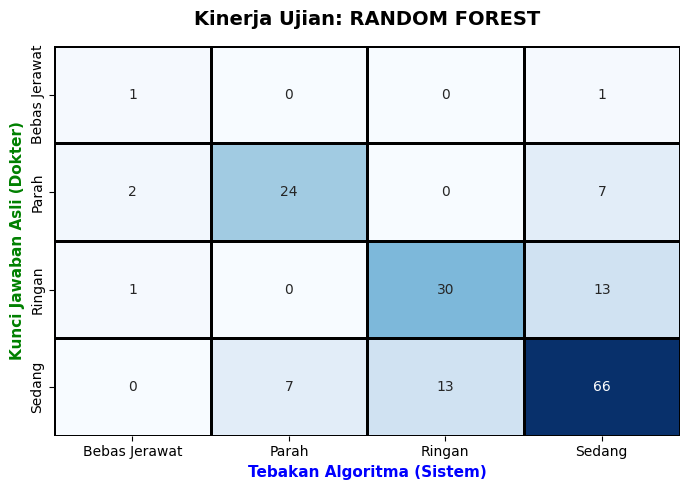

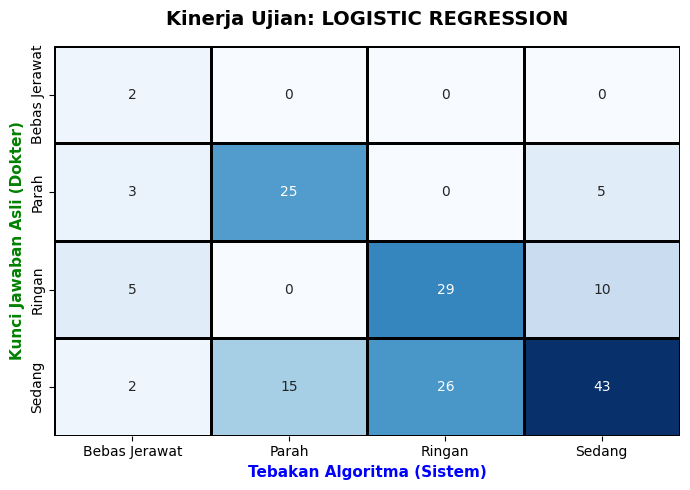

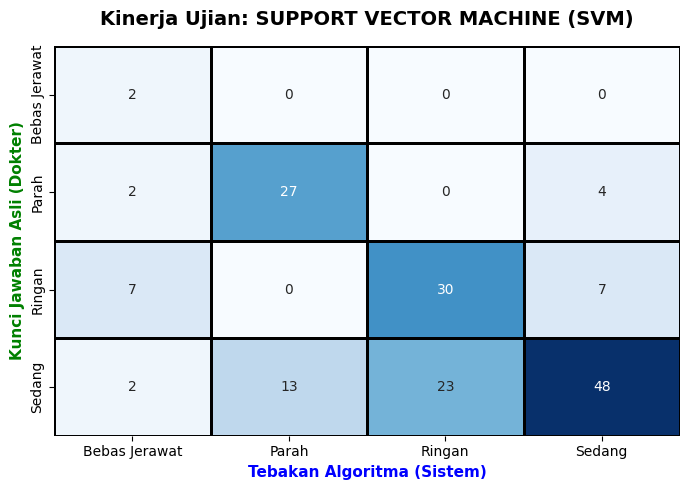

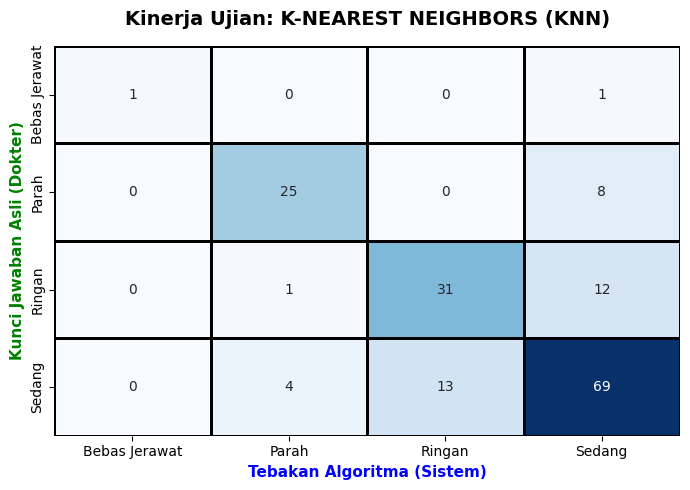

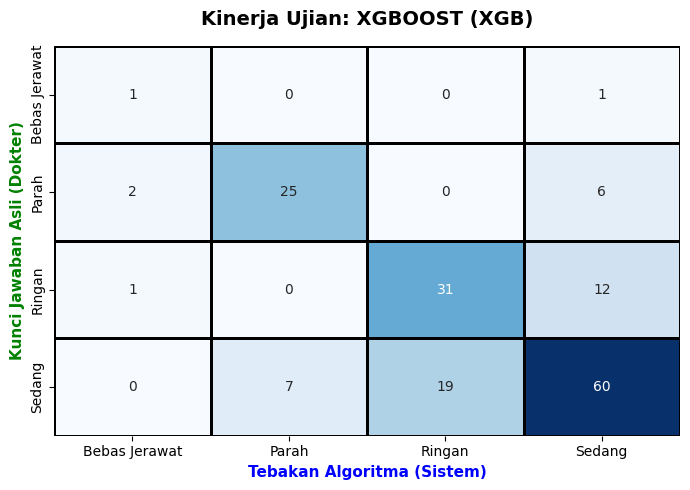

In [ ]:
from sklearn.metrics import confusion_matrix

# ==========================================
# 9. VISUALISASI RAPOR (CONFUSION MATRIX HEATMAP)
# ==========================================

# Ambil urutan kategori yang benar dari data ujian agar urutannya rapi
label_kelas = np.unique(y_test)

print("="*55)
print("MENCETAK HEATMAP CONFUSION MATRIX UNTUK 6 ALGORITMA")
print("="*55)

# Loop untuk menggambar heatmap setiap mesin yang sudah ujian
for nama_model, mesin in daftar_model.items():
    # Suruh mesin menebak ulang dari soal ujian
    tebakan_mesin = mesin.predict(X_test_scaled)

    # --- PENYELAMAT KHUSUS XGBOOST ---
    # Terjemahkan dulu angka sandi XGBoost jadi teks biasa
    if nama_model == "XGBOOST (XGB)":
        tebakan_mesin = le.inverse_transform(tebakan_mesin)

    # Hitung matriks kebingungannya (Confusion Matrix)
    cm = confusion_matrix(y_test, tebakan_mesin, labels=label_kelas)

    # Atur ukuran kanvas gambar biar pas, tidak terlalu besar/kecil
    plt.figure(figsize=(7, 5))

    # Gambar heatmap pakai Seaborn
    # fmt='d' artinya tampilkan angka utuh (bukan desimal/eksponensial)
    # cmap='Blues' untuk gradasi warna biru (makin gelap makin banyak angkanya)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=label_kelas, yticklabels=label_kelas,
                linewidths=1, linecolor='black')

    # Kasih judul dan label yang jelas
    plt.title(f'Kinerja Ujian: {nama_model}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Tebakan Algoritma (Sistem)', fontsize=11, fontweight='bold', color='blue')
    plt.ylabel('Kunci Jawaban Asli (Dokter)', fontsize=11, fontweight='bold', color='green')

    # Tampilkan gambarnya!
    plt.tight_layout()
    plt.show()

## Ujicoba dengan data test dengan perlakuan Skin Masking

In [ ]:
import os
import cv2
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# UJIAN FINAL: MENGADU TEBAKAN VS KUNCI JAWABAN
# ==========================================

folder_test_images = 'data/test/images'
folder_test_labels = 'data/test/labels'

y_kunci_jawaban = []
y_tebakan_mesin = []

ekstensi_valid = ('.jpg', '.jpeg', '.png')
foto_test = [f for f in os.listdir(folder_test_images) if f.lower().endswith(ekstensi_valid)]

print(f"Memulai Ujian Final untuk {len(foto_test)} pasien dari desa seberang...\n")

# Siapkan alat cuci (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

for nama_foto in foto_test:
    path_foto = os.path.join(folder_test_images, nama_foto)
    nama_txt = os.path.splitext(nama_foto)[0] + '.txt'
    path_txt = os.path.join(folder_test_labels, nama_txt)

    # 1. AMBIL KUNCI JAWABAN DARI DOKTER ASLI
    kategori_asli, _, _, _ = tentukan_label_dari_yolo(path_txt)

    # 2. BACA GAMBAR SOAL UJIAN MENTAH
    img = cv2.imread(path_foto)
    if img is None: continue

    # --- PROSES PENCUCIAN VIRTUAL (MASKING + CLAHE) ---
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    img_YCrCb = cv2.cvtColor(img_blur, cv2.COLOR_BGR2YCrCb)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    mask = cv2.inRange(img_YCrCb, lower_skin, upper_skin)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    # img_final inilah yang bersih dan siap dimakan YOLO
    img_final = cv2.bitwise_and(img_clahe, img_clahe, mask=mask)
    # --------------------------------------------------

    h_img, w_img, _ = img_final.shape
    luas_kanvas = h_img * w_img

    # 3. MATA (YOLO) MENCARI JERAWAT DI GAMBAR YANG SUDAH DICUCI
    hasil_yolo = model_yolo.predict(source=img_final, conf=0.25, verbose=False)

    kotak_yolo = hasil_yolo[0].boxes.xywh.cpu().numpy()
    skor_yolo = hasil_yolo[0].boxes.conf.cpu().numpy() # Ambil skor keyakinan

    jml_jerawat = len(kotak_yolo)
    luas_total = 0.0
    luas_terbesar = 0.0

    for kotak in kotak_yolo:
        area_px = kotak[2] * kotak[3]
        luas_total += area_px
        if area_px > luas_terbesar:
            luas_terbesar = area_px

    luas_terbesar_norm = luas_terbesar / luas_kanvas if luas_kanvas > 0 else 0
    luas_total_norm = luas_total / luas_kanvas if luas_kanvas > 0 else 0
    rata_conf = float(np.mean(skor_yolo)) if jml_jerawat > 0 else 0.0

    # 4. OTAK (MACHINE LEARNING) MEMBERIKAN TEBAKAN
    # HATI-HATI: Pastikan fiturnya ada 4 sesuai yang kita latih tadi!
    fitur_mentah = np.array([[jml_jerawat, luas_terbesar_norm, luas_total_norm, rata_conf]])
    fitur_scaled = scaler.transform(fitur_mentah)

    # Di sini kamu bisa ganti model_rf dengan model_xgboost kalau XGBoost yang menang
    vonis_keparahan = model_rf.predict(fitur_scaled)[0]

    # 5. KUMPULKAN KERTAS UJIAN
    y_kunci_jawaban.append(kategori_asli)
    y_tebakan_mesin.append(vonis_keparahan)

# ==========================================
# PEMBAGIAN RAPOR AKHIR
# ==========================================
print("\n" + "="*55)
print("HASIL UJIAN FINAL (DATA TEST UNSEEN)")
print("="*55)
akurasi_final = accuracy_score(y_kunci_jawaban, y_tebakan_mesin)
print(f"Akurasi Keseluruhan : {akurasi_final * 100:.2f}%\n")
print("Detail Rapor (Precision, Recall, F1-Score):")
print(classification_report(y_kunci_jawaban, y_tebakan_mesin, zero_division=0))
print("="*55)

Memulai Ujian Final untuk 48 pasien dari desa seberang...



c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: U


HASIL UJIAN FINAL (DATA TEST UNSEEN)
Akurasi Keseluruhan : 81.25%

Detail Rapor (Precision, Recall, F1-Score):
               precision    recall  f1-score   support

Bebas Jerawat       0.00      0.00      0.00         0
        Parah       0.50      0.50      0.50         2
       Ringan       1.00      0.67      0.80        18
       Sedang       0.79      0.93      0.85        28

     accuracy                           0.81        48
    macro avg       0.57      0.52      0.54        48
 weighted avg       0.86      0.81      0.82        48



c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## DEPLOY STREAMLIT

In [ ]:
import joblib

# Simpan Random Forest dan Scaler ke dalam file .pkl
joblib.dump(model_rf, 'rf_jerawat_model.pkl')
joblib.dump(scaler, 'scaler_jerawat.pkl')

print("Otak Random Forest dan Scaler berhasil dibekukan dan disimpan!")

Otak Random Forest dan Scaler berhasil dibekukan dan disimpan!


In [ ]:
import cv2
import numpy as np
import joblib
from ultralytics import YOLO

# 1. Muat kembali model yang sudah disimpan
mata_yolo = YOLO('runs/detect/train/weights/best.pt')
otak_rf = joblib.load('rf_jerawat_model.pkl')
alat_scaler = joblib.load('scaler_jerawat.pkl')

# 2. Siapkan alat cuci
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

def deteksi_jerawat_user(path_gambar):
    # Baca gambar
    img = cv2.imread(path_gambar)
    if img is None:
        return "Gambar tidak ditemukan!", None

    # --- PENCUCIAN VIRTUAL (Sama persis seperti saat training) ---
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    img_YCrCb = cv2.cvtColor(img_blur, cv2.COLOR_BGR2YCrCb)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    mask = cv2.inRange(img_YCrCb, lower_skin, upper_skin)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    img_final = cv2.bitwise_and(img_clahe, img_clahe, mask=mask)
    # -----------------------------------------------------------

    h_img, w_img, _ = img_final.shape
    luas_kanvas = h_img * w_img

    # Deteksi YOLO
    hasil_yolo = mata_yolo.predict(source=img_final, conf=0.25, verbose=False)
    kotak_yolo = hasil_yolo[0].boxes.xywh.cpu().numpy()
    skor_yolo = hasil_yolo[0].boxes.conf.cpu().numpy()

    # Hitung Statistik
    jml_jerawat = len(kotak_yolo)
    luas_total = 0.0
    luas_terbesar = 0.0

    for kotak in kotak_yolo:
        area_px = kotak[2] * kotak[3]
        luas_total += area_px
        if area_px > luas_terbesar:
            luas_terbesar = area_px

    luas_terbesar_norm = luas_terbesar / luas_kanvas if luas_kanvas > 0 else 0
    luas_total_norm = luas_total / luas_kanvas if luas_kanvas > 0 else 0
    rata_conf = float(np.mean(skor_yolo)) if jml_jerawat > 0 else 0.0

    # Random Forest menebak
    fitur = np.array([[jml_jerawat, luas_terbesar_norm, luas_total_norm, rata_conf]])
    fitur_scaled = alat_scaler.transform(fitur)
    vonis = otak_rf.predict(fitur_scaled)[0]

    # Kembalikan vonis dan gambar hasil gambar kotak YOLO untuk dipamerkan
    img_hasil_kotak = hasil_yolo[0].plot()
    return vonis, img_hasil_kotak

c:\Users\Advan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


HASIL DIAGNOSIS SISTEM: SEDANG


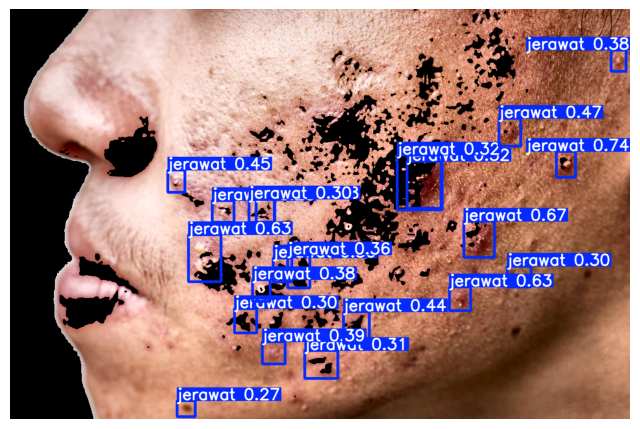

In [ ]:
import matplotlib.pyplot as plt

# Masukkan path fotomu sendiri di sini!
foto_tester = 'test_gmbar.jpg'

hasil_vonis, gambar_terdeteksi = deteksi_jerawat_user(foto_tester)

print("="*40)
print(f"HASIL DIAGNOSIS SISTEM: {hasil_vonis.upper()}")
print("="*40)

# Tampilkan visualisasinya
if gambar_terdeteksi is not None:
    plt.figure(figsize=(8,8))
    # Ubah BGR ke RGB agar warnanya normal di Matplotlib
    plt.imshow(cv2.cvtColor(gambar_terdeteksi, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [ ]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
import joblib
from ultralytics import YOLO
from PIL import Image

# 1. Konfigurasi Halaman (Biar rapi)
st.set_page_config(page_title="Deteksi Jerawat", page_icon="🩺", layout="centered")

st.title("🩺 Deteksi Tingkat Keparahan Jerawat pada Kulit Wajah")
st.markdown("Unggah foto wajahmu, dan biarkan Sistem menganalisis tingkat keparahan jerawat dalam hitungan detik!")
st.write("---")

# 2. Muat Model (Pakai st.cache_resource agar web tidak lemot me-load ulang model terus menerus)
@st.cache_resource
def load_models():
    mata_yolo = YOLO('runs/detect/train/weights/best.pt') # Ganti path kalau beda
    otak_rf = joblib.load('rf_jerawat_model.pkl')
    alat_scaler = joblib.load('scaler_jerawat.pkl')
    return mata_yolo, otak_rf, alat_scaler

mata_yolo, otak_rf, alat_scaler = load_models()
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# 3. Fitur Upload Gambar
file_upload = st.file_uploader("Pilih foto wajah (Format JPG/PNG)", type=['jpg', 'jpeg', 'png'])

if file_upload is not None:
    # Ubah file yang diupload menjadi format yang bisa dibaca OpenCV
    image_pil = Image.open(file_upload).convert('RGB')
    img_bgr = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)

    st.write("Menganalisis wajah...")
    progress_bar = st.progress(0)

    # --- PENCUCIAN VIRTUAL ---
    progress_bar.progress(30)
    img_blur = cv2.GaussianBlur(img_bgr, (5, 5), 0)
    img_YCrCb = cv2.cvtColor(img_blur, cv2.COLOR_BGR2YCrCb)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    mask = cv2.inRange(img_YCrCb, lower_skin, upper_skin)

    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    img_final = cv2.bitwise_and(img_clahe, img_clahe, mask=mask)

    h_img, w_img, _ = img_final.shape
    luas_kanvas = h_img * w_img

    # --- DETEKSI YOLO ---
    progress_bar.progress(60)
    hasil_yolo = mata_yolo.predict(source=img_final, conf=0.25, verbose=False)
    kotak_yolo = hasil_yolo[0].boxes.xywh.cpu().numpy()
    skor_yolo = hasil_yolo[0].boxes.conf.cpu().numpy()

    jml_jerawat = len(kotak_yolo)
    luas_total = 0.0
    luas_terbesar = 0.0

    for kotak in kotak_yolo:
        area_px = kotak[2] * kotak[3]
        luas_total += area_px
        if area_px > luas_terbesar:
            luas_terbesar = area_px

    luas_terbesar_norm = luas_terbesar / luas_kanvas if luas_kanvas > 0 else 0
    luas_total_norm = luas_total / luas_kanvas if luas_kanvas > 0 else 0
    rata_conf = float(np.mean(skor_yolo)) if jml_jerawat > 0 else 0.0

    # --- VONIS RANDOM FOREST ---
    progress_bar.progress(90)
    fitur = np.array([[jml_jerawat, luas_terbesar_norm, luas_total_norm, rata_conf]])
    fitur_scaled = alat_scaler.transform(fitur)
    vonis = otak_rf.predict(fitur_scaled)[0]

    # Gambar kotak jerawat ke foto asli (bukan yang hitam-hitam) biar user gak takut
    img_pamer = hasil_yolo[0].plot(img=img_bgr)
    progress_bar.progress(100)

    # 4. Tampilkan Hasil yang Cantik
    st.write("---")
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Foto Asli")
        st.image(image_pil, use_column_width=True)
    with col2:
        st.subheader("Hasil Analisis")
        st.image(cv2.cvtColor(img_pamer, cv2.COLOR_BGR2RGB), use_column_width=True)

    st.write("---")
    st.markdown("<h3 style='text-align: center;'>Vonis AI:</h3>", unsafe_allow_html=True)

    # Bikin warna-warni tergantung keparahannya
    if vonis == "Bebas Jerawat":
        st.success(f"🌟 KONDISI KULIT: {vonis.upper()}")
    elif vonis == "Ringan":
        st.info(f"🟢 KONDISI KULIT: {vonis.upper()}")
    elif vonis == "Sedang":
        st.warning(f"🟡 KONDISI KULIT: {vonis.upper()}")
    else:
        st.error(f"🔴 KONDISI KULIT: {vonis.upper()}")

    st.write(f"**Statistik:** Sistem mendeteksi **{jml_jerawat}** area jerawat.")

Writing app.py


## Visualisasi Hasil Deteksi YOLO vs Dataset Asli

⏳ Menampilkan 2 gambar perbandingan...
🎨 Membuat visualisasi perbandingan...

✓ acne-286_jpeg.rf.1b6bcca440593ac6e33617083f34a4c5.jpg: GT=18, YOLO=18
✓ acne-167_jpg.rf.ca7f225b1a40cb053f3f590585061393.jpg: GT=10, YOLO=4


C:\Users\Advan\AppData\Local\Temp\ipykernel_15508\3861146081.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


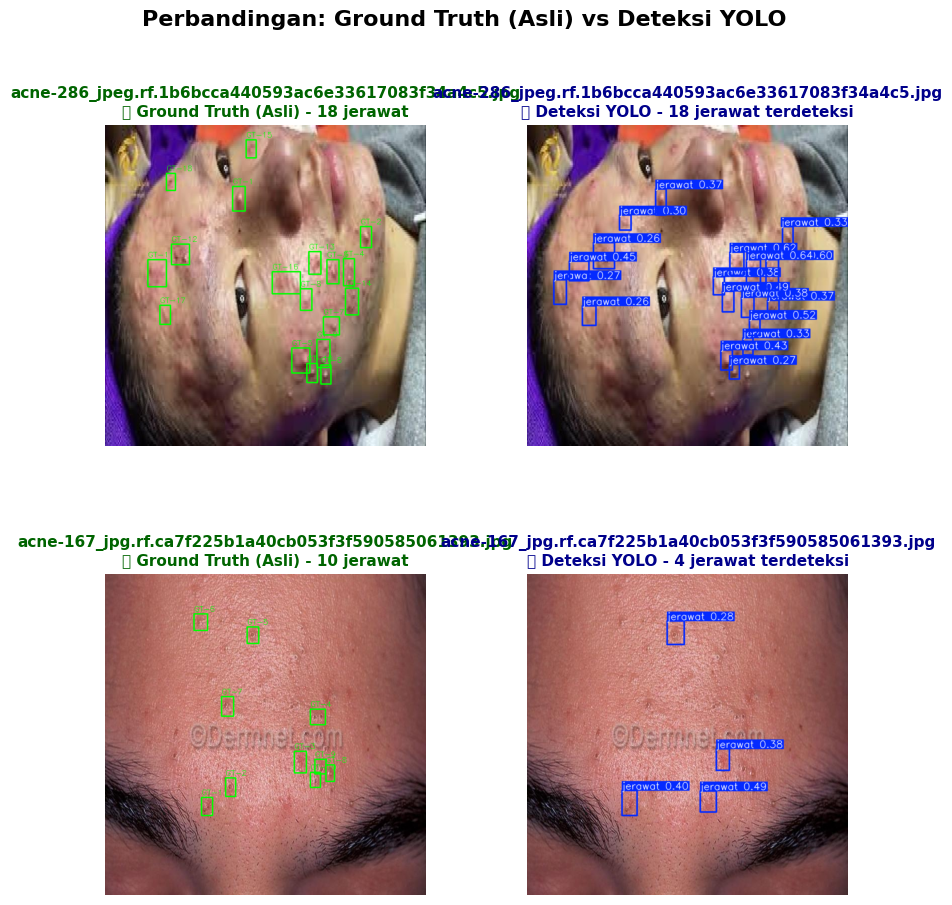


✅ Visualisasi perbandingan selesai!


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

# Siapkan alat cuci (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# Load model YOLO yang sudah dilatih
from ultralytics import YOLO
model = YOLO('runs/detect/train/weights/best.pt')

# Tentukan folder yang akan divisualisasi
test_img_folder = 'data/test/images'
test_label_folder = 'data/test/labels'

# Ambil list gambar dari test set
list_gambar = [f for f in os.listdir(test_img_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# ⚡ Acak sampel untuk visualisasi
jumlah_sampel = 2  # Ubah angka ini untuk lebih banyak gambar
sampel_gambar = random.sample(list_gambar, min(jumlah_sampel, len(list_gambar)))

print(f"⏳ Menampilkan {len(sampel_gambar)} gambar perbandingan...")

# Buat figure dengan subplot (2 kolom: Ground Truth vs YOLO)
fig = plt.figure(figsize=(10, 5 * len(sampel_gambar)))
gs = GridSpec(len(sampel_gambar), 2, figure=fig, hspace=0.4, wspace=0.2)

print("🎨 Membuat visualisasi perbandingan...\n")

for idx, nama_gambar in enumerate(sampel_gambar):
    path_img = os.path.join(test_img_folder, nama_gambar)
    
    # Baca gambar asli
    img_asli = cv2.imread(path_img)
    if img_asli is None:
        continue
    
    img_rgb = cv2.cvtColor(img_asli, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img_asli.shape
    
    # === KOLOM 1: GROUND TRUTH (Dari File Annotation) ===
    nama_label = nama_gambar.rsplit('.', 1)[0] + '.txt'
    path_label = os.path.join(test_label_folder, nama_label)
    img_gt = img_rgb.copy()
    jumlah_gt = 0
    
    if os.path.exists(path_label):
        with open(path_label, 'r') as f:
            for line in f:
                data_box = line.strip().split()
                if len(data_box) == 5:
                    jumlah_gt += 1
                    x_center, y_center, width, height = map(float, data_box[1:])
                    # Konversi dari format YOLO (normalized) ke pixel koordinat
                    x1 = int((x_center - width/2) * w_img)
                    y1 = int((y_center - height/2) * h_img)
                    x2 = int((x_center + width/2) * w_img)
                    y2 = int((y_center + height/2) * h_img)
                    # Gambar bounding box dengan warna HIJAU (ground truth)
                    cv2.rectangle(img_gt, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(img_gt, f"GT-{jumlah_gt}", (x1, y1-5), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    
    # === KOLOM 2: HASIL DETEKSI YOLO ===
    # Preprocessing (sama seperti saat training)
    img_blur = cv2.GaussianBlur(img_asli, (5, 5), 0)
    img_YCrCb = cv2.cvtColor(img_blur, cv2.COLOR_BGR2YCrCb)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    mask = cv2.inRange(img_YCrCb, lower_skin, upper_skin)
    
    lab = cv2.cvtColor(img_asli, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    img_preprocessed = cv2.bitwise_and(img_clahe, img_clahe, mask=mask)
    
    # Deteksi YOLO pada gambar yang sudah dipreprocess
    hasil_yolo = model.predict(source=img_preprocessed, conf=0.25, verbose=False)
    
    # Gambar hasil deteksi YOLO pada gambar asli (biar kelihatan natural)
    img_yolo_result = hasil_yolo[0].plot(img=img_asli)
    img_yolo_result_rgb = cv2.cvtColor(img_yolo_result, cv2.COLOR_BGR2RGB)
    
    # Hitung jumlah deteksi YOLO
    jumlah_yolo = len(hasil_yolo[0].boxes)
    
    # === TAMPILKAN DI SUBPLOT ===
    # Subplot Kolom 1: Ground Truth
    ax1 = fig.add_subplot(gs[idx, 0])
    ax1.imshow(img_gt)
    ax1.set_title(f'{nama_gambar}\n📗 Ground Truth (Asli) - {jumlah_gt} jerawat', 
                  fontsize=11, fontweight='bold', color='darkgreen')
    ax1.axis('off')
    
    # Subplot Kolom 2: YOLO Detection
    ax2 = fig.add_subplot(gs[idx, 1])
    ax2.imshow(img_yolo_result_rgb)
    ax2.set_title(f'{nama_gambar}\n🤖 Deteksi YOLO - {jumlah_yolo} jerawat terdeteksi', 
                  fontsize=11, fontweight='bold', color='darkblue')
    ax2.axis('off')
    
    print(f"✓ {nama_gambar}: GT={jumlah_gt}, YOLO={jumlah_yolo}")

plt.suptitle('Perbandingan: Ground Truth (Asli) vs Deteksi YOLO', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✅ Visualisasi perbandingan selesai!")